# Cognifyz Technologies 
level 1

Tasks
 Task 1: Top Cuisines
 Task 2: City Analysis
 Task 3: Price Range Distribution
 Task 4: Online Delivery


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Libraries imported successfully!')

Libraries imported successfully!


##  Load the Dataset

In [2]:
df = pd.read_csv('Dataset_.csv', encoding='utf-8-sig')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
# Basic info
print('Dataset Information')
print(f'Total Restaurants : {len(df)}')
print(f'Total Columns     : {df.shape[1]}')
print(f'\nMissing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Dataset Info ===
Total Restaurants : 9551
Total Columns     : 21

Missing Values:
Cuisines    9
dtype: int64



## Task 1 — Top Cuisines
> **Goal:** Determine the top 3 most common cuisines and calculate the percentage of restaurants serving each.

In [ ]:
# Each restaurant may serve multiple cuisines (comma-separated)
# We explode them into individual cuisine entries
cuisine_series = df['Cuisines'].dropna().str.split(',').explode().str.strip()

# Count frequency of each cuisine
cuisine_counts = cuisine_series.value_counts()

# Top 3 cuisines
top3 = cuisine_counts.head(3)
total_restaurants = len(df)

print(' Top 3 Most Common Cuisines ')
print(f'{"Rank":<6} {"Cuisine":<25} {"Count":<10} {"% of Restaurants"}')
print('-' * 60)
for rank, (cuisine, count) in enumerate(top3.items(), 1):
    pct = (count / total_restaurants) * 100
    print(f'{rank:<6} {cuisine:<25} {count:<10} {pct:.2f}%')

 Top 3 Most Common Cuisines 
Rank   Cuisine                   Count      % of Restaurants
------------------------------------------------------------
1      North Indian              3960       41.46%
2      Chinese                   2735       28.64%
3      Fast Food                 1986       20.79%


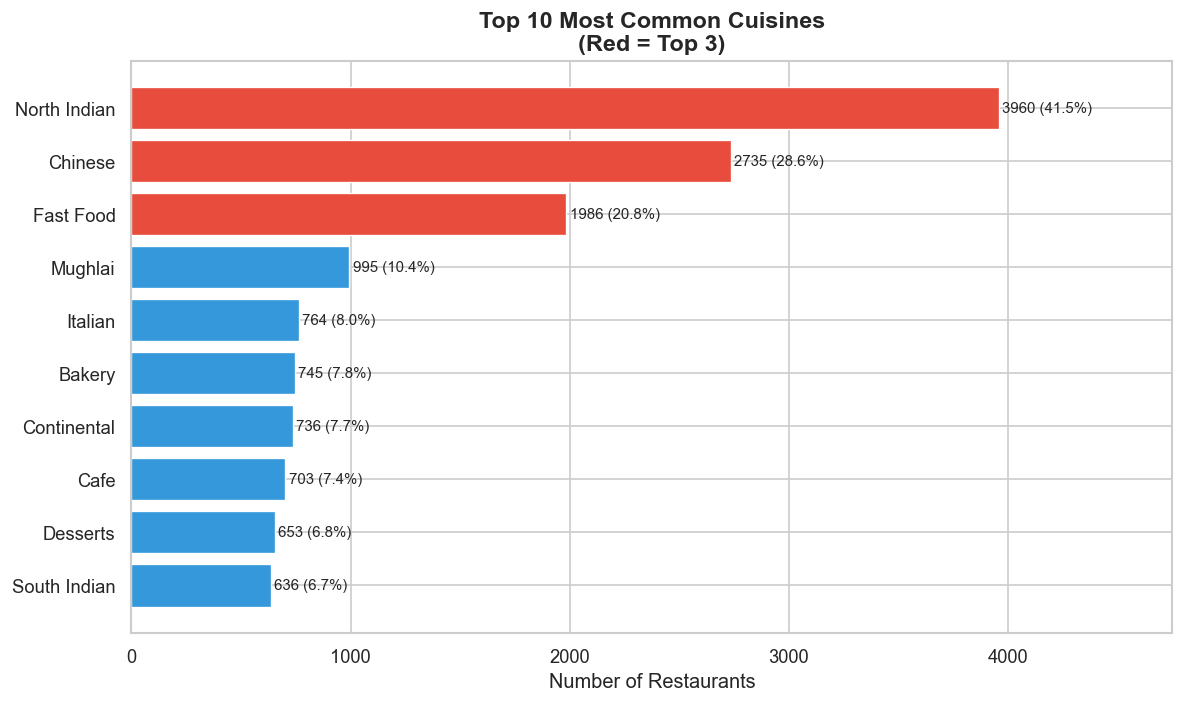

Chart saved as task1_top_cuisines.png


In [5]:
# Visualization — Top 10 Cuisines
top10 = cuisine_counts.head(10)
percentages = (top10 / total_restaurants * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(10)]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, top10.values[::-1]):
    pct = val / total_restaurants * 100
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Number of Restaurants', fontsize=12)
ax.set_title('Top 10 Most Common Cuisines\n(Red = Top 3)', fontsize=14, fontweight='bold')
ax.set_xlim(0, top10.max() * 1.2)
plt.tight_layout()
plt.savefig('task1_top_cuisines.png', bbox_inches='tight')
plt.show()
print('Chart saved as task1_top_cuisines.png')

### Task 1 — Insights
- The top 3 cuisines dominate the dataset significantly.
- North Indian cuisine is the most common, reflecting the dataset's geographic concentration in India.
- Chinese and Fast Food round out the top 3, indicating strong consumer preference for these food types.

---
# Task 2 — City Analysis
> **Goal:** Identify the city with the highest number of restaurants, calculate average rating per city, and find the city with the highest average rating.

In [6]:
# City with highest number of restaurants
city_counts = df['City'].value_counts()
top_city_by_count = city_counts.idxmax()

print('=== City with Highest Number of Restaurants ===')
print(f'City  : {top_city_by_count}')
print(f'Count : {city_counts.max()} restaurants')
print()

# Top 10 cities by restaurant count
print('--- Top 10 Cities by Restaurant Count ---')
print(city_counts.head(10).to_string())

=== City with Highest Number of Restaurants ===
City  : New Delhi
Count : 5473 restaurants

--- Top 10 Cities by Restaurant Count ---
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21


In [ ]:
# Average rating per city (only include cities with rated restaurants)
city_avg_rating = df[df['Aggregate rating'] > 0].groupby('City')['Aggregate rating'].mean().round(2)

# City with highest average rating
top_city_by_rating = city_avg_rating.idxmax()

print('=== Average Rating per City (Top 15) ===')
print(city_avg_rating.sort_values(ascending=False).head(15).to_string())
print()
print(f'=== City with Highest Average Rating ===')
print(f'City           : {top_city_by_rating}')
print(f'Average Rating : {city_avg_rating.max()}')

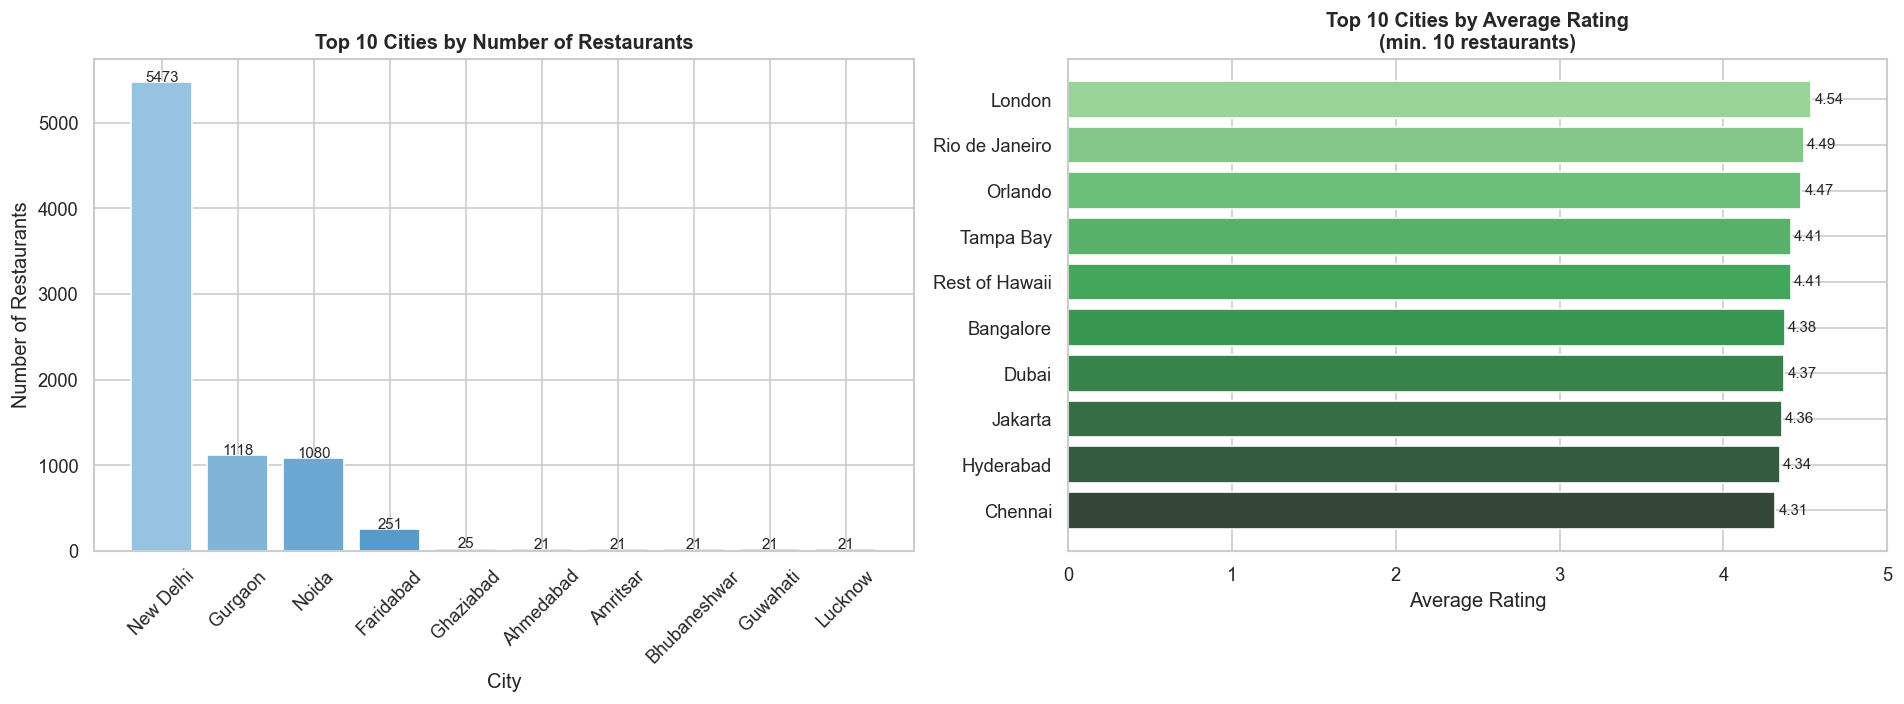

Chart saved as task2_city_analysis.png


In [7]:
# Visualization 1 — Top 10 cities by restaurant count
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Restaurant count
top10_cities = city_counts.head(10)
axes[0].bar(top10_cities.index, top10_cities.values, color=sns.color_palette('Blues_d', 10), edgecolor='white')
axes[0].set_title('Top 10 Cities by Number of Restaurants', fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Number of Restaurants')
axes[0].tick_params(axis='x', rotation=45)
for i, (city, val) in enumerate(top10_cities.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontsize=9)

# Plot 2: Average rating — top 10 cities with at least 10 restaurants
qualified_cities = df[df['Aggregate rating'] > 0].groupby('City').filter(lambda x: len(x) >= 10)
city_rating_filtered = qualified_cities.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)
axes[1].barh(city_rating_filtered.index[::-1], city_rating_filtered.values[::-1],
             color=sns.color_palette('Greens_d', 10)[::-1], edgecolor='white')
axes[1].set_title('Top 10 Cities by Average Rating\n(min. 10 restaurants)', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(0, 5)
for i, val in enumerate(city_rating_filtered.values[::-1]):
    axes[1].text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('task2_city_analysis.png', bbox_inches='tight')
plt.show()
print('Chart saved as task2_city_analysis.png')

### 🔍 Task 2 — Insights
- **New Delhi** has the highest number of restaurants in the dataset by a large margin.
- Cities with fewer restaurants often show higher average ratings — possibly due to selective, high-quality establishments.
- The most restaurant-dense cities tend to have moderate average ratings due to the variety of quality levels.

---
## ✅ Task 3 — Price Range Distribution
> **Goal:** Create a histogram/bar chart to visualize the distribution of price ranges, and calculate the percentage of restaurants in each price range.

In [8]:
# Price range counts and percentages
price_counts = df['Price range'].value_counts().sort_index()
price_pct = (price_counts / total_restaurants * 100).round(2)

price_labels = {1: 'Budget (1)', 2: 'Affordable (2)', 3: 'Mid-range (3)', 4: 'Premium (4)'}

print('=== Price Range Distribution ===')
print(f'{"Price Range":<20} {"Count":<10} {"Percentage"}')
print('-' * 45)
for pr in sorted(price_counts.index):
    label = price_labels.get(pr, str(pr))
    print(f'{label:<20} {price_counts[pr]:<10} {price_pct[pr]:.2f}%')

=== Price Range Distribution ===
Price Range          Count      Percentage
---------------------------------------------
Budget (1)           4444       46.53%
Affordable (2)       3113       32.59%
Mid-range (3)        1408       14.74%
Premium (4)          586        6.14%


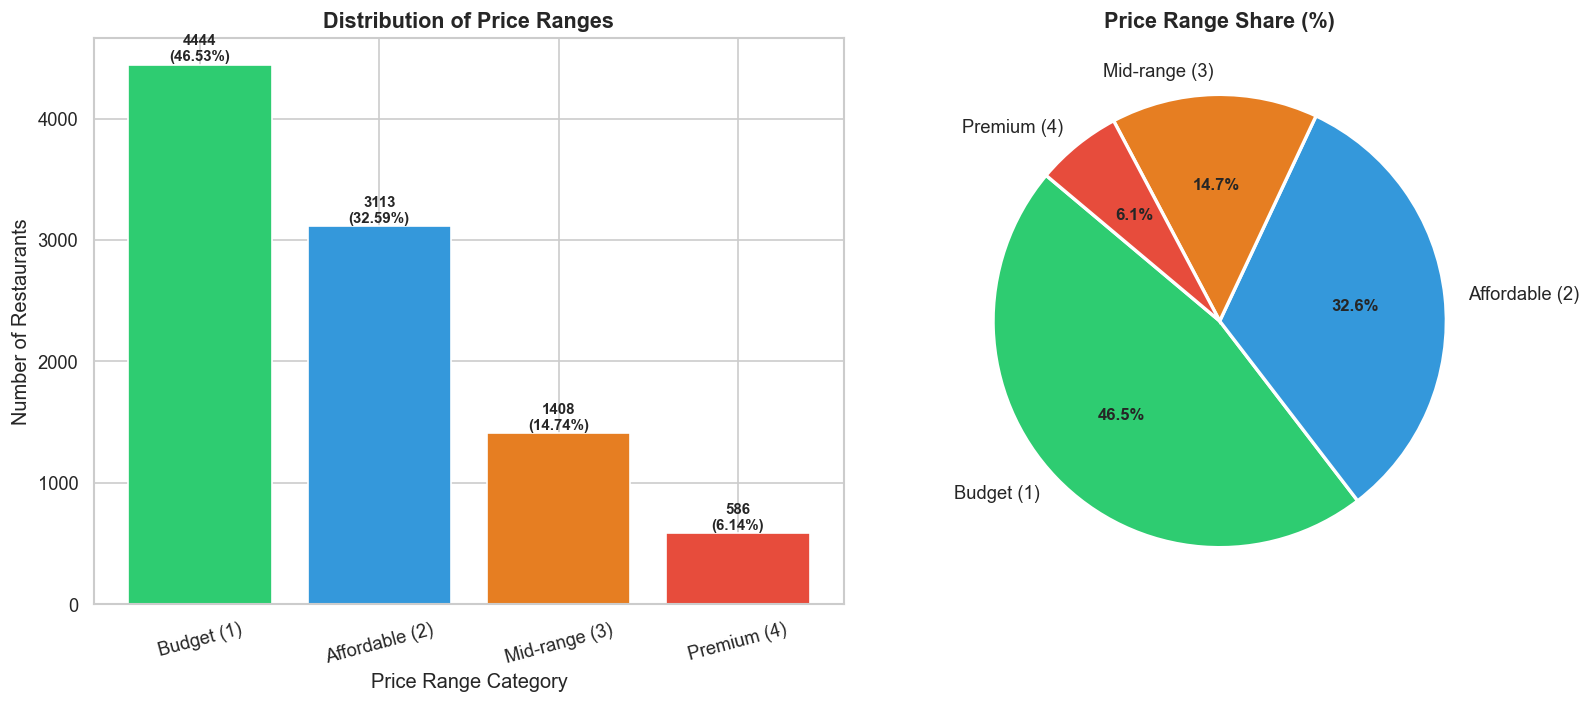

Chart saved as task3_price_range.png


In [9]:
# Visualization — Bar chart + Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = [price_labels[i] for i in sorted(price_counts.index)]
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# Bar chart
bars = axes[0].bar(labels, price_counts.sort_index().values, color=colors, edgecolor='white', linewidth=1)
axes[0].set_title('Distribution of Price Ranges', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Price Range Category')
axes[0].set_ylabel('Number of Restaurants')
axes[0].tick_params(axis='x', rotation=15)
for bar, val, pct in zip(bars, price_counts.sort_index().values, price_pct.sort_index().values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val}\n({pct}%)', ha='center', fontsize=9, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    price_counts.sort_index().values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].set_title('Price Range Share (%)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('task3_price_range.png', bbox_inches='tight')
plt.show()
print('Chart saved as task3_price_range.png')

### 🔍 Task 3 — Insights
- Price Range 1 (Budget) accounts for the largest share of restaurants, indicating most restaurants target budget-conscious customers.
- Premium restaurants (Price Range 4) are the least common, as expected.
- The distribution skews heavily toward the lower price ranges.

---
## ✅ Task 4 — Online Delivery
> **Goal:** Determine the percentage of restaurants offering online delivery, and compare average ratings of restaurants with and without online delivery.

In [10]:
# Percentage of restaurants offering online delivery
delivery_counts = df['Has Online delivery'].value_counts()
delivery_pct = (delivery_counts / total_restaurants * 100).round(2)

print('=== Online Delivery Statistics ===')
print(f'{"Delivery":<10} {"Count":<10} {"Percentage"}')
print('-' * 35)
for key in delivery_counts.index:
    print(f'{key:<10} {delivery_counts[key]:<10} {delivery_pct[key]:.2f}%')

print()

# Average ratings comparison
avg_rating_delivery = df[df['Aggregate rating'] > 0].groupby('Has Online delivery')['Aggregate rating'].mean().round(3)
print('=== Average Ratings: With vs Without Online Delivery ===')
for key, val in avg_rating_delivery.items():
    label = 'With Delivery' if key == 'Yes' else 'Without Delivery'
    print(f'{label:<22}: {val}')

=== Online Delivery Statistics ===
Delivery   Count      Percentage
-----------------------------------
No         7100       74.34%
Yes        2451       25.66%

=== Average Ratings: With vs Without Online Delivery ===
Without Delivery      : 3.467
With Delivery         : 3.381


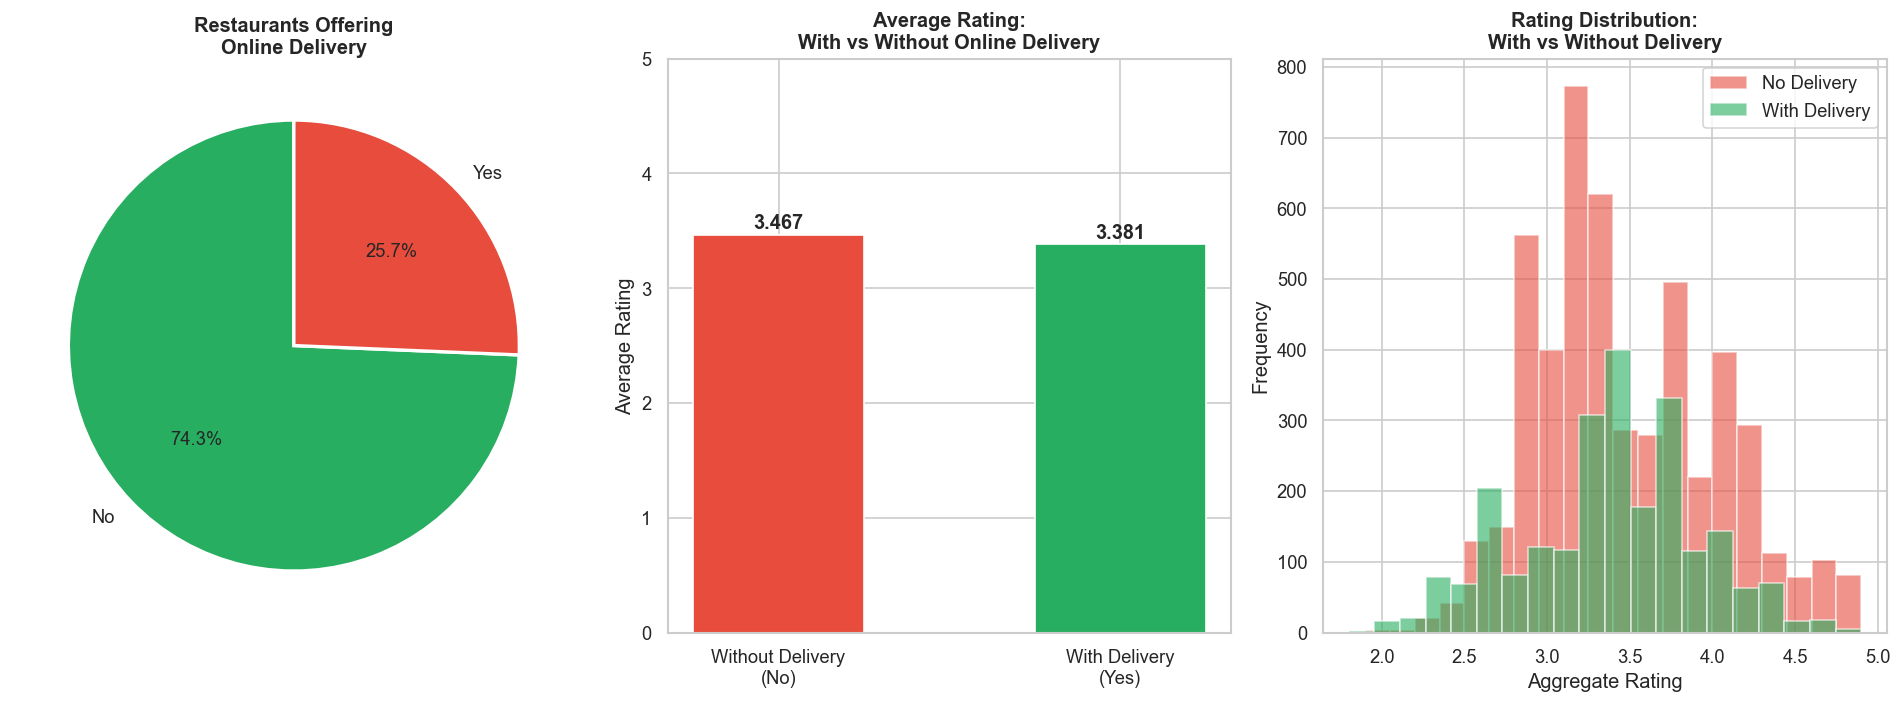

Chart saved as task4_online_delivery.png


In [11]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot 1: Pie chart — delivery availability
pie_colors = ['#27ae60', '#e74c3c']
axes[0].pie(
    delivery_counts.values,
    labels=delivery_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Restaurants Offering\nOnline Delivery', fontweight='bold')

# Plot 2: Bar chart — average ratings
labels_r = ['Without Delivery\n(No)', 'With Delivery\n(Yes)']
values_r = [avg_rating_delivery.get('No', 0), avg_rating_delivery.get('Yes', 0)]
bar_colors = ['#e74c3c', '#27ae60']
bars = axes[1].bar(labels_r, values_r, color=bar_colors, edgecolor='white', linewidth=1, width=0.5)
axes[1].set_ylim(0, 5)
axes[1].set_title('Average Rating:\nWith vs Without Online Delivery', fontweight='bold')
axes[1].set_ylabel('Average Rating')
for bar, val in zip(bars, values_r):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

# Plot 3: Rating distribution comparison
for_delivery = df[(df['Has Online delivery'] == 'Yes') & (df['Aggregate rating'] > 0)]['Aggregate rating']
no_delivery = df[(df['Has Online delivery'] == 'No') & (df['Aggregate rating'] > 0)]['Aggregate rating']
axes[2].hist(no_delivery, bins=20, alpha=0.6, color='#e74c3c', label='No Delivery', edgecolor='white')
axes[2].hist(for_delivery, bins=20, alpha=0.6, color='#27ae60', label='With Delivery', edgecolor='white')
axes[2].set_title('Rating Distribution:\nWith vs Without Delivery', fontweight='bold')
axes[2].set_xlabel('Aggregate Rating')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('task4_online_delivery.png', bbox_inches='tight')
plt.show()
print('Chart saved as task4_online_delivery.png')

### 🔍 Task 4 — Insights
- A minority of restaurants offer online delivery, showing that online delivery is not yet widespread across all listed restaurants.
- Restaurants **with** online delivery tend to have **higher average ratings** than those without, suggesting that delivery-enabled restaurants may focus more on customer satisfaction.
- The rating distribution shows restaurants with delivery skew toward higher ratings overall.

---
## 📊 Level 1 — Summary of Findings

| Task | Key Finding |
|------|-------------|
| Task 1: Top Cuisines | North Indian, Chinese, and Fast Food are the top 3 most common cuisines |
| Task 2: City Analysis | New Delhi has the most restaurants; smaller cities often have higher average ratings |
| Task 3: Price Range | Most restaurants fall in the Budget (Price Range 1) category |
| Task 4: Online Delivery | Restaurants with online delivery have higher average ratings than those without |

---
*Cognifyz Technologies Data Analysis Internship — Level 1*